In [1]:
import pandas as pd


In [2]:
df = pd.read_excel("leakeage_prediction.xlsx")

In [3]:
print(df.shape)

(5000, 13)


In [4]:
print(df.columns.tolist())

['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours', 'Zone', 'Block', 'Pipe', 'Location_Code', 'Latitude', 'Longitude', 'Leakage_Flag']


In [5]:
display(df.head())

,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Zone,Block,Pipe,Location_Code,Latitude,Longitude,Leakage_Flag
0,64.967142,73.643605,96.607526,2.928288,2104.485874,3380,Zone_4,Block_2,Pipe_3,Zone_4_Block_2_Pipe_3,25.162560,55.238018,0
1,58.617357,73.198788,98.472503,2.983672,2084.997078,2235,Zone_3,Block_4,Pipe_1,Zone_3_Block_4_Pipe_1,25.090473,55.162476,0
2,66.476885,53.065352,97.013095,3.032147,1719.044046,8762,Zone_2,Block_2,Pipe_5,Zone_2_Block_2_Pipe_5,25.279196,55.287601,0
3,75.230299,75.048647,100.552090,3.473431,2173.875267,8931,Zone_5,Block_3,Pipe_2,Zone_5_Block_3_Pipe_2,25.198326,55.269765,0
4,57.658466,90.992436,105.985893,2.626391,1552.975197,3403,Zone_3,Block_1,Pipe_1,Zone_3_Block_1_Pipe_1,25.099630,55.166098,0


In [6]:
print(df.dtypes)

Pressure             float64
Flow_Rate            float64
Temperature          float64
Vibration            float64
RPM                  float64
Operational_Hours      int64
Zone                  object
Block                 object
Pipe                  object
Location_Code         object
Latitude             float64
Longitude            float64
Leakage_Flag           int64
dtype: object


In [7]:
print(df.isnull().sum())


Pressure             0
Flow_Rate            0
Temperature          0
Vibration            0
RPM                  0
Operational_Hours    0
Zone                 0
Block                0
Pipe                 0
Location_Code        0
Latitude             0
Longitude            0
Leakage_Flag         0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


In [9]:
df.describe()


,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Latitude,Longitude,Leakage_Flag
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000
mean,5.939695e+09,8.465789e+09,3.798405e+09,6.586515e+08,1994.494314,5488.247800,1.513508e+09,1.105992e+08,0.064600
std,1.889653e+11,2.602947e+11,1.899550e+11,4.657370e+10,295.012393,2611.426293,6.177638e+10,7.820537e+09,0.245843
min,2.758733e+01,2.116400e+01,8.312210e+01,1.071812e+00,903.474045,1000.000000,2.508139e+01,5.514602e+01,0.000000
25%,5.342986e+01,6.971347e+01,9.669752e+01,2.667660e+00,1789.471968,3197.500000,2.514525e+01,5.522561e+01,0.000000
50%,6.014211e+01,7.975406e+01,1.000546e+02,3.009630e+00,1997.594952,5489.000000,2.519318e+01,5.527052e+01,0.000000
75%,6.668677e+01,9.019818e+01,1.033824e+02,3.353458e+00,2195.181932,7748.500000,2.520767e+01,5.528575e+01,0.000000
max,6.695203e+12,9.992249e+12,9.721918e+12,3.293258e+12,3083.405019,9998.000000,2.527401e+12,5.529955e+11,1.000000


In [10]:
numeric_columns = [
    'Pressure',
    'Flow_Rate',
    'Temperature',
    'Vibration',
    'RPM',
    'Operational_Hours',
    'Latitude',
    'Longitude'
]



In [11]:
for column in numeric_columns:
    print(f"\n===== {column} =====")
    print(df.nlargest(5, column)[[column, 'Leakage_Flag']])


===== Pressure =====
          Pressure  Leakage_Flag
3223  6.695203e+12             0
2669  6.625631e+12             0
198   6.058209e+12             0
4379  5.223501e+12             0
3321  5.095932e+12             0

===== Flow_Rate =====
         Flow_Rate  Leakage_Flag
1595  9.992249e+12             1
2867  9.215390e+12             1
4041  8.443498e+12             0
2113  6.576877e+12             0
538   6.151353e+12             0

===== Temperature =====
       Temperature  Leakage_Flag
2358  9.721918e+12             0
2987  9.270107e+12             0
3225  1.171446e+02             0
1338  1.168888e+02             0
1464  1.164388e+02             0

===== Vibration =====
         Vibration  Leakage_Flag
431   3.293258e+12             0
843   5.239542e+00             0
3851  4.971166e+00             0
2436  4.548348e+00             0
2380  4.535668e+00             1

===== RPM =====
              RPM  Leakage_Flag
1620  3083.405019             0
126   3080.849641             0
33

In [12]:
'df' in globals()

True

In [13]:
print(df[['Pressure', 'Flow_Rate', 'Temperature', 'Vibration',
          'RPM', 'Operational_Hours', 'Latitude', 'Longitude']].quantile(
          [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]
))

          Pressure     Flow_Rate   Temperature     Vibration          RPM  \
0.00  2.758733e+01  2.116400e+01  8.312210e+01  1.071812e+00   903.474045   
0.01  3.636980e+01  4.543535e+01  8.815479e+01  1.807411e+00  1322.188188   
0.05  4.386360e+01  5.467631e+01  9.191159e+01  2.202521e+00  1515.697088   
0.25  5.342986e+01  6.971347e+01  9.669752e+01  2.667660e+00  1789.471968   
0.50  6.014211e+01  7.975406e+01  1.000546e+02  3.009630e+00  1997.594952   
0.75  6.668677e+01  9.019818e+01  1.033824e+02  3.353458e+00  2195.181932   
0.95  7.645193e+01  1.049775e+02  1.082011e+02  3.842092e+00  2477.976613   
0.99  8.320277e+01  1.166200e+02  1.118420e+02  4.170431e+00  2658.190189   
1.00  6.695203e+12  9.992249e+12  9.721918e+12  3.293258e+12  3083.405019   

      Operational_Hours      Latitude     Longitude  
0.00            1000.00  2.508139e+01  5.514602e+01  
0.01            1071.99  2.508729e+01  5.515626e+01  
0.05            1441.00  2.509234e+01  5.516027e+01  
0.25         

In [14]:
df.loc[df['Pressure'] > 200, 'Pressure'] /= 10**11

df.loc[df['Flow_Rate'] >= 10**12, 'Flow_Rate'] /= 10**11

df.loc[
    (df['Flow_Rate'] >= 10**11) &
    (df['Flow_Rate'] < 10**12),
    'Flow_Rate'
] /= 10**10

df.loc[df['Temperature'] > 300, 'Temperature'] /= 10**11

df.loc[df['Vibration'] > 50, 'Vibration'] /= 10**12

df.loc[df['Latitude'] > 100, 'Latitude'] /= 10**11

df.loc[df['Longitude'] > 100, 'Longitude'] /= 10**10

In [15]:
df.describe()

,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Latitude,Longitude,Leakage_Flag
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,60.056019,79.833875,100.052765,3.008258,1994.494314,5488.247800,25.183972,55.248892,0.064600
std,9.964798,15.186005,4.993849,0.501668,295.012393,2611.426293,0.059976,0.047702,0.245843
min,27.587327,10.008990,83.122104,1.071812,903.474045,1000.000000,25.081389,55.146015,0.000000
25%,53.420950,69.699206,96.695568,2.667660,1789.471968,3197.500000,25.145249,55.225614,0.000000
50%,60.134656,79.729781,100.049587,3.009630,1997.594952,5489.000000,25.193184,55.270521,0.000000
75%,66.660106,90.149437,103.377671,3.353307,2195.181932,7748.500000,25.207640,55.285752,0.000000
max,99.262377,132.935828,117.144552,5.239542,3083.405019,9998.000000,25.291945,55.312817,1.000000


In [16]:
clean_df = df.copy()

In [17]:
limits = {
    'Pressure': 200,
    'Flow_Rate': 300,
    'Temperature': 300,
    'Vibration': 50,
    'RPM': 5000,
    'Operational_Hours': 15000,
    'Latitude': 100,
    'Longitude': 100
}

for column, limit in limits.items():
    suspicious = clean_df[clean_df[column] > limit]
    
    print(f"\n{column}: {len(suspicious)} suspicious values")
    
    if len(suspicious) > 0:
        print(suspicious[[column, 'Leakage_Flag']])


Pressure: 0 suspicious values

Flow_Rate: 0 suspicious values

Temperature: 0 suspicious values

Vibration: 0 suspicious values

RPM: 0 suspicious values

Operational_Hours: 0 suspicious values

Latitude: 0 suspicious values

Longitude: 0 suspicious values


In [18]:

clean_df.loc[clean_df['Pressure'] > 200, 'Pressure'] /= 10**11
clean_df.loc[clean_df['Flow_Rate'] >= 10**12, 'Flow_Rate'] /= 10**11
clean_df.loc[ (clean_df['Flow_Rate'] >= 10**11) & (clean_df['Flow_Rate'] < 10**12), 'Flow_Rate'] /= 10**10

clean_df.loc[clean_df['Temperature'] > 300, 'Temperature'] /= 10**11
clean_df.loc[clean_df['Vibration'] > 50, 'Vibration'] /= 10**12
clean_df.loc[clean_df['Latitude'] > 100, 'Latitude'] /= 10**11
clean_df.loc[clean_df['Longitude'] > 100, 'Longitude'] /= 10**10

In [19]:
print(df.describe())


          Pressure    Flow_Rate  Temperature    Vibration          RPM  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     60.056019    79.833875   100.052765     3.008258  1994.494314   
std       9.964798    15.186005     4.993849     0.501668   295.012393   
min      27.587327    10.008990    83.122104     1.071812   903.474045   
25%      53.420950    69.699206    96.695568     2.667660  1789.471968   
50%      60.134656    79.729781   100.049587     3.009630  1997.594952   
75%      66.660106    90.149437   103.377671     3.353307  2195.181932   
max      99.262377   132.935828   117.144552     5.239542  3083.405019   

       Operational_Hours     Latitude    Longitude  Leakage_Flag  
count        5000.000000  5000.000000  5000.000000   5000.000000  
mean         5488.247800    25.183972    55.248892      0.064600  
std          2611.426293     0.059976     0.047702      0.245843  
min          1000.000000    25.081389    55.146015      0.000000 

In [20]:
print("Maximum values after correction:\n")

columns_to_check = [
'Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours','Latitude','Longitude']

for column in columns_to_check:
    print(f"{column}: {df[column].max()}")

Maximum values after correction:

Pressure: 99.26237706436326
Flow_Rate: 132.93582781355727
Temperature: 117.14455239004108
Vibration: 5.239542125512879
RPM: 3083.405018844701
Operational_Hours: 9998
Latitude: 25.291945353486263
Longitude: 55.31281728311812


In [21]:
print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)

Original shape: (5000, 13)
Cleaned shape: (5000, 13)


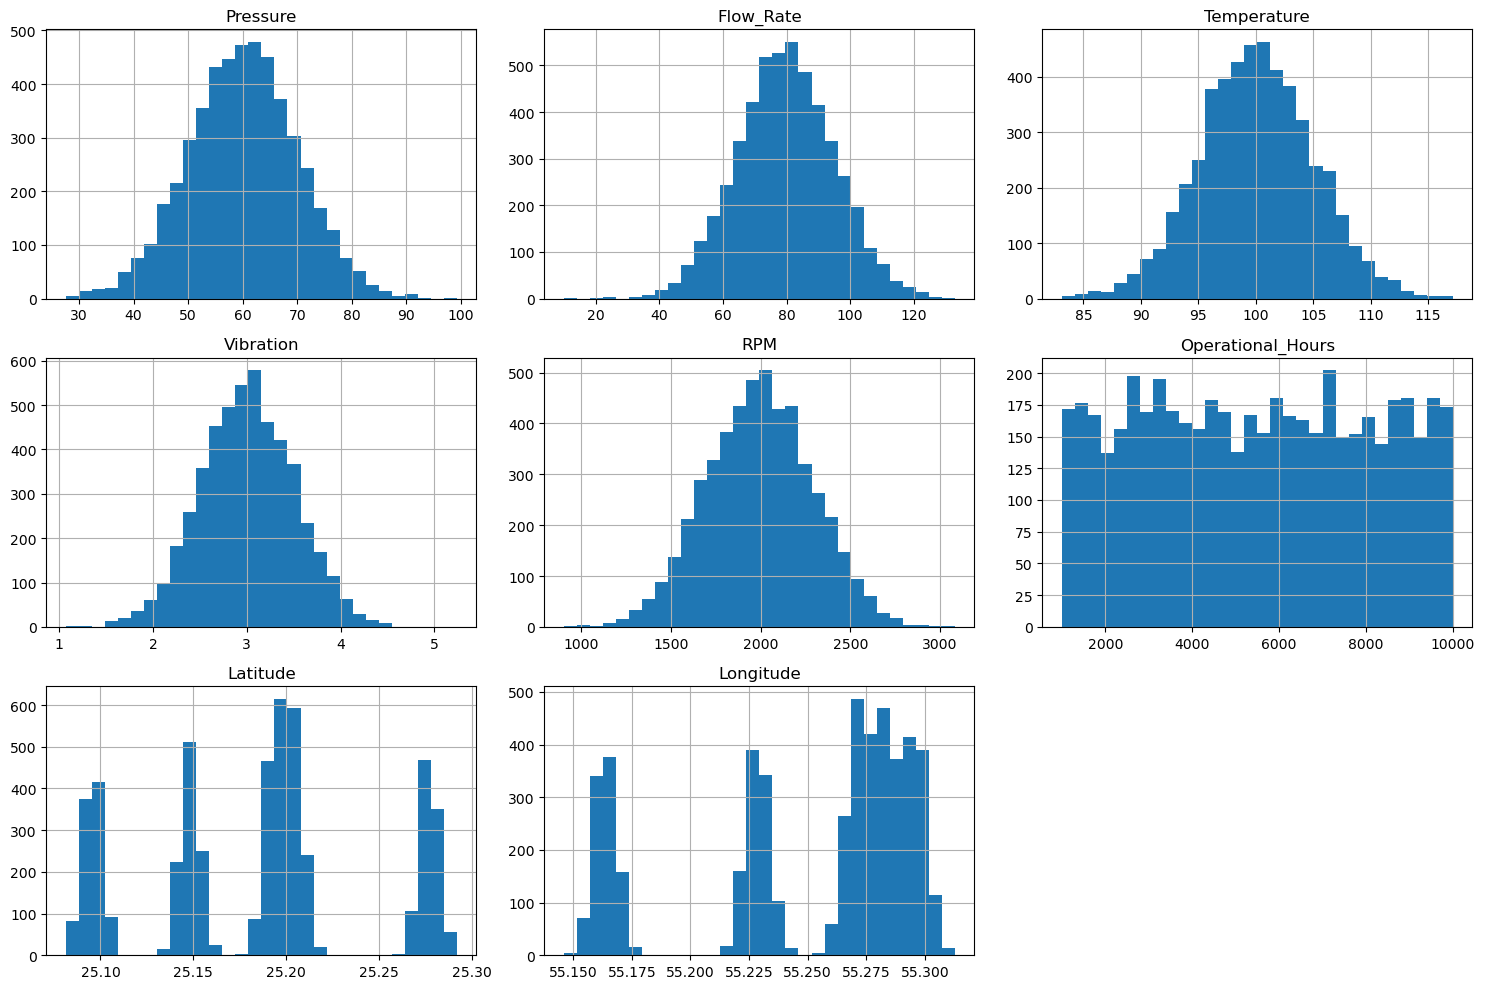

In [22]:
import matplotlib.pyplot as plt

df[numeric_columns].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

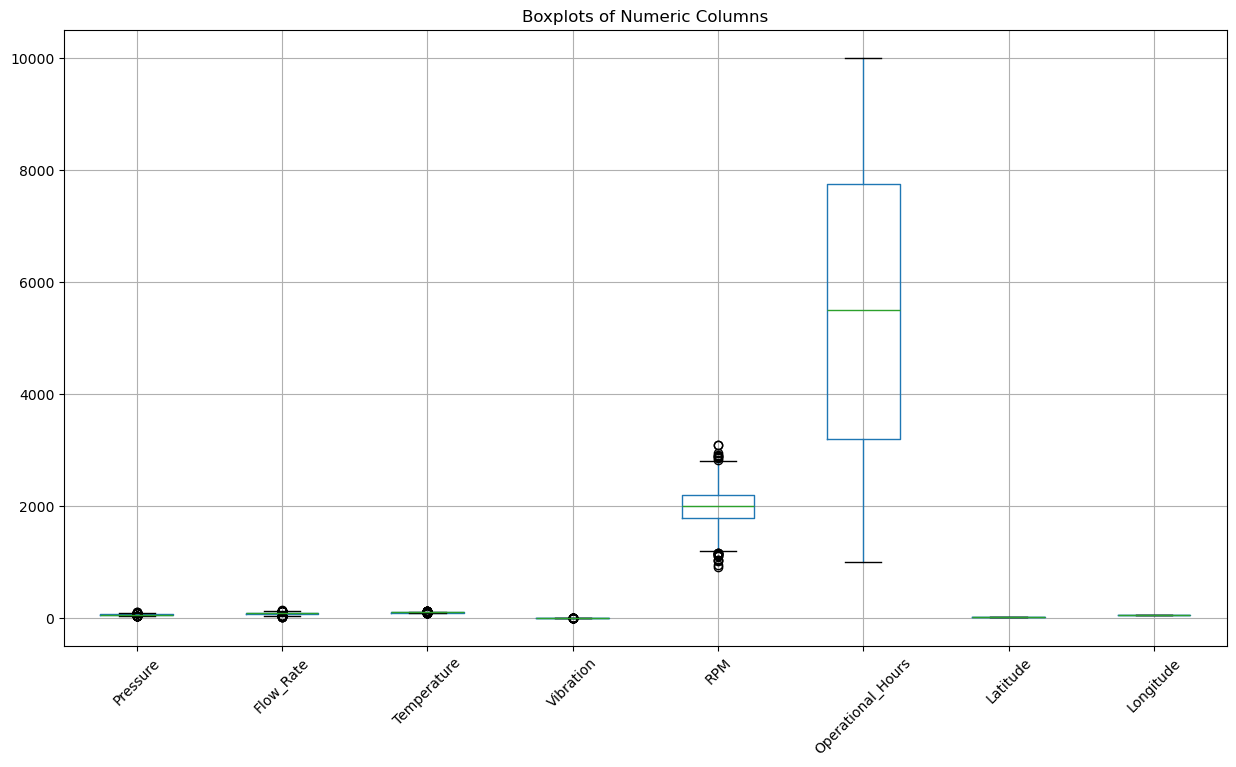

In [23]:
plt.figure(figsize=(15, 8))
df[numeric_columns].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Columns")
plt.show()

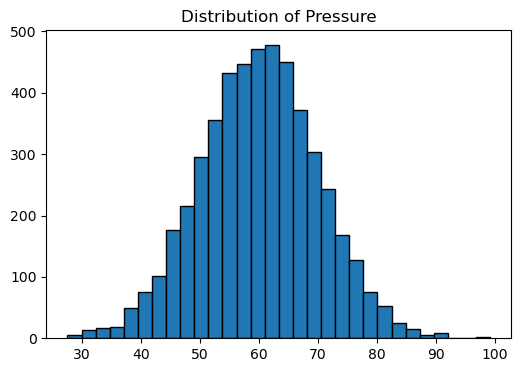

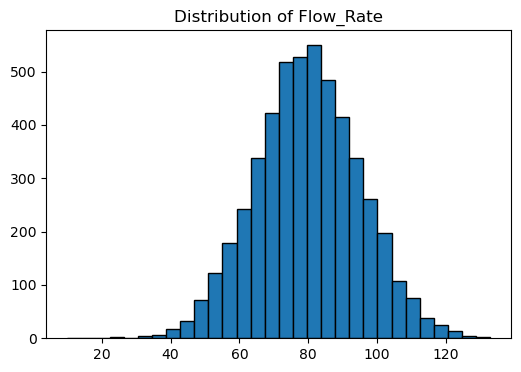

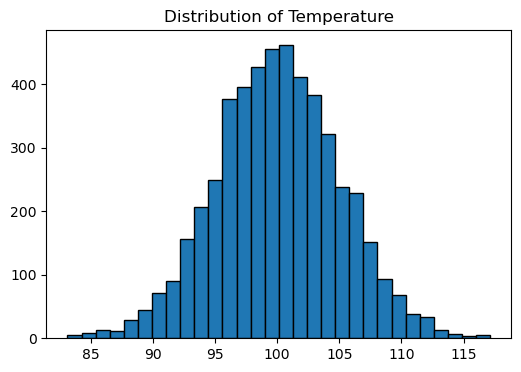

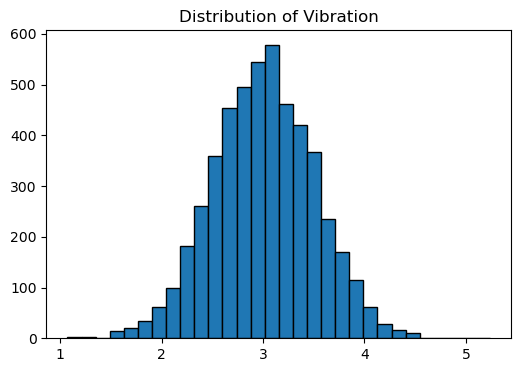

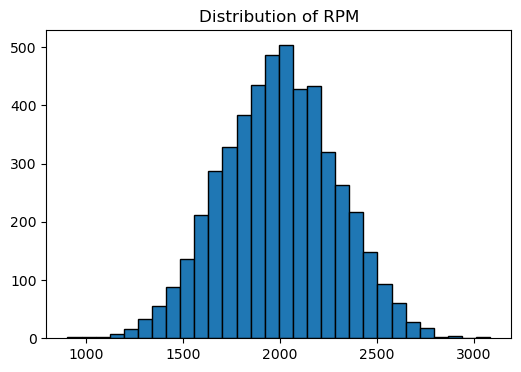

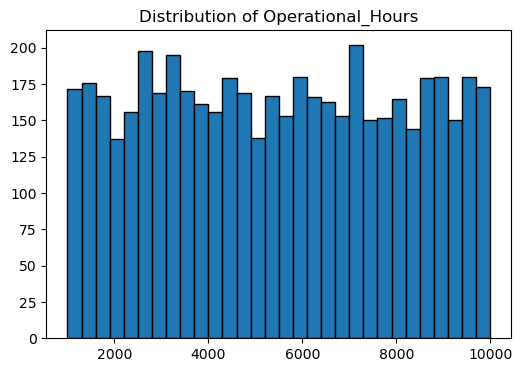

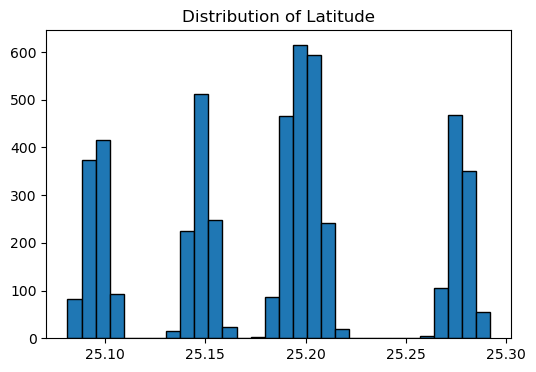

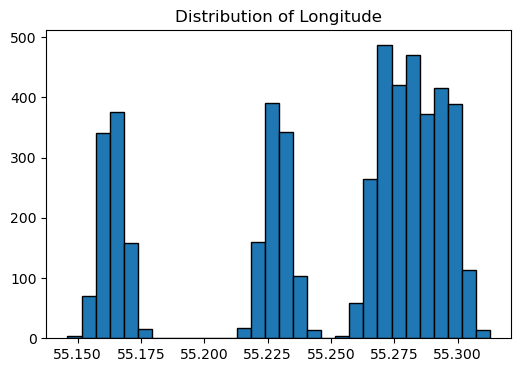

In [24]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.show()

In [25]:
from scipy import stats
import numpy as np

iqr_columns = ['Pressure', 'Flow_Rate', 'Vibration', 'Operational_Hours']
zscore_columns = ['RPM', 'Temperature']

for col in iqr_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers (IQR method)")

for col in zscore_columns:
    z_scores = stats.zscore(df[col])
    outliers = df[(abs(z_scores) > 3)]
    print(f"{col}: {len(outliers)} outliers (Z-score method)")
    
invalid_lat = df[(df['Latitude'] < -90) | (df['Latitude'] > 90)]
invalid_lon = df[(df['Longitude'] < -180) | (df['Longitude'] > 180)]
print(f"Latitude invalid: {len(invalid_lat)}")
print(f"Longitude invalid: {len(invalid_lon)}")


Pressure: 42 outliers (IQR method)
Flow_Rate: 36 outliers (IQR method)
Vibration: 36 outliers (IQR method)
Operational_Hours: 0 outliers (IQR method)
RPM: 13 outliers (Z-score method)
Temperature: 18 outliers (Z-score method)
Latitude invalid: 0
Longitude invalid: 0


In [26]:

for col in iqr_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]


for col in zscore_columns:
    z_scores = stats.zscore(df[col])
    df = df[(abs(z_scores) <= 3)]


df = df[(df['Latitude'] >= -90) & (df['Latitude'] <= 90)]
df = df[(df['Longitude'] >= -180) & (df['Longitude'] <= 180)]


In [27]:
print(df.shape)


(4857, 13)


In [28]:
df.to_csv("cleaned_leakeage_dataset.csv", index=False)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
#EXPLORATORY DATA ANALYSIS
df.to_csv("cleaned_leakeage_dataset.csv", index=False)

In [31]:
#UNIVARIATE ANALYSIS

In [32]:
categorical_cols = ['Zone', 'Block', 'Pipe', 'Location_Code']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [33]:
print(df_encoded.head())
print(df_encoded.dtypes)

    Pressure  Flow_Rate  Temperature  Vibration          RPM  \
0  64.967142  73.643605    96.607526   2.928288  2104.485874   
1  58.617357  73.198788    98.472503   2.983672  2084.997078   
2  66.476885  53.065352    97.013095   3.032147  1719.044046   
3  75.230299  75.048647   100.552090   3.473431  2173.875267   
4  57.658466  90.992436   105.985893   2.626391  1552.975197   

   Operational_Hours   Latitude  Longitude  Leakage_Flag  Zone_Zone_2  ...  \
0               3380  25.162560  55.238018             0        False  ...   
1               2235  25.090473  55.162476             0        False  ...   
2               8762  25.279196  55.287601             0         True  ...   
3               8931  25.198326  55.269765             0        False  ...   
4               3403  25.099630  55.166098             0        False  ...   

   Location_Code_Zone_5_Block_4_Pipe_1  Location_Code_Zone_5_Block_4_Pipe_2  \
0                                False                             

In [34]:
df.to_csv("cleaned_leakeage_dataset.csv", index=False)


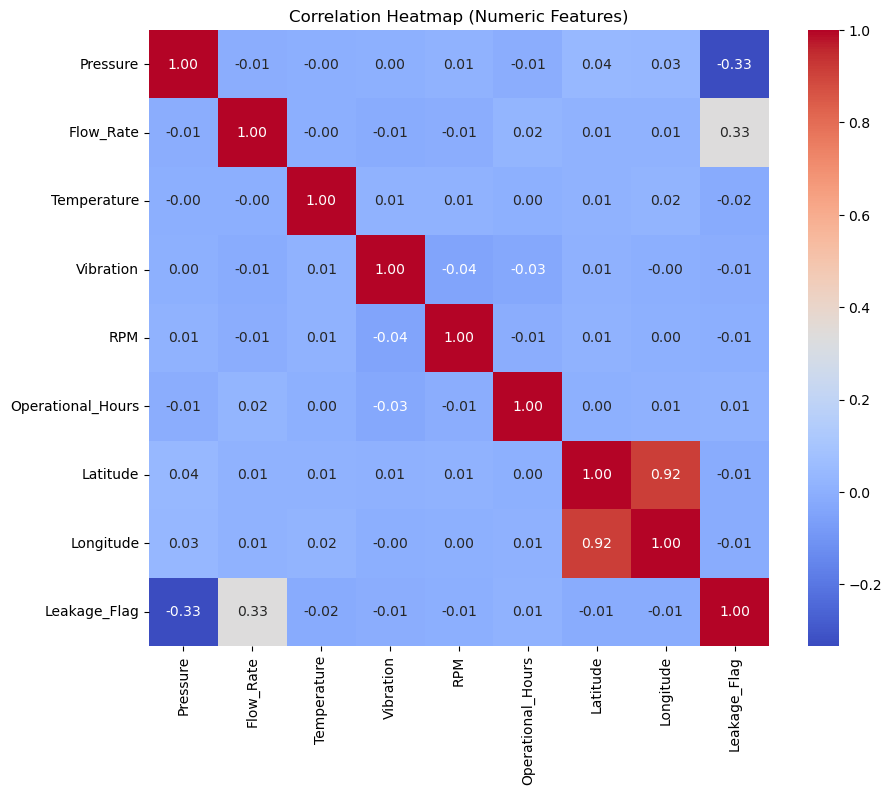

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_columns + ['Leakage_Flag']].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [36]:
df.describe()

,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Latitude,Longitude,Leakage_Flag
count,4857.000000,4857.000000,4857.000000,4857.000000,4857.000000,4857.000000,4857.000000,4857.000000,4857.000000
mean,60.090586,79.946905,100.058134,3.009713,1995.603612,5484.746963,25.184247,55.249094,0.064855
std,9.609439,14.743291,4.919960,0.485778,291.276059,2605.245046,0.060014,0.047641,0.246295
min,33.642523,39.310812,85.133469,1.672459,1131.744483,1000.000000,25.081389,55.146015,0.000000
25%,53.493402,69.824981,96.707632,2.670912,1790.701146,3201.000000,25.145291,55.225740,0.000000
50%,60.141493,79.800430,100.050106,3.009629,1997.970622,5481.000000,25.193229,55.270613,0.000000
75%,66.594512,90.189407,103.392748,3.349288,2195.580020,7744.000000,25.207725,55.285871,0.000000
max,86.443433,120.828682,114.847548,4.376615,2880.081712,9998.000000,25.291945,55.312817,1.000000


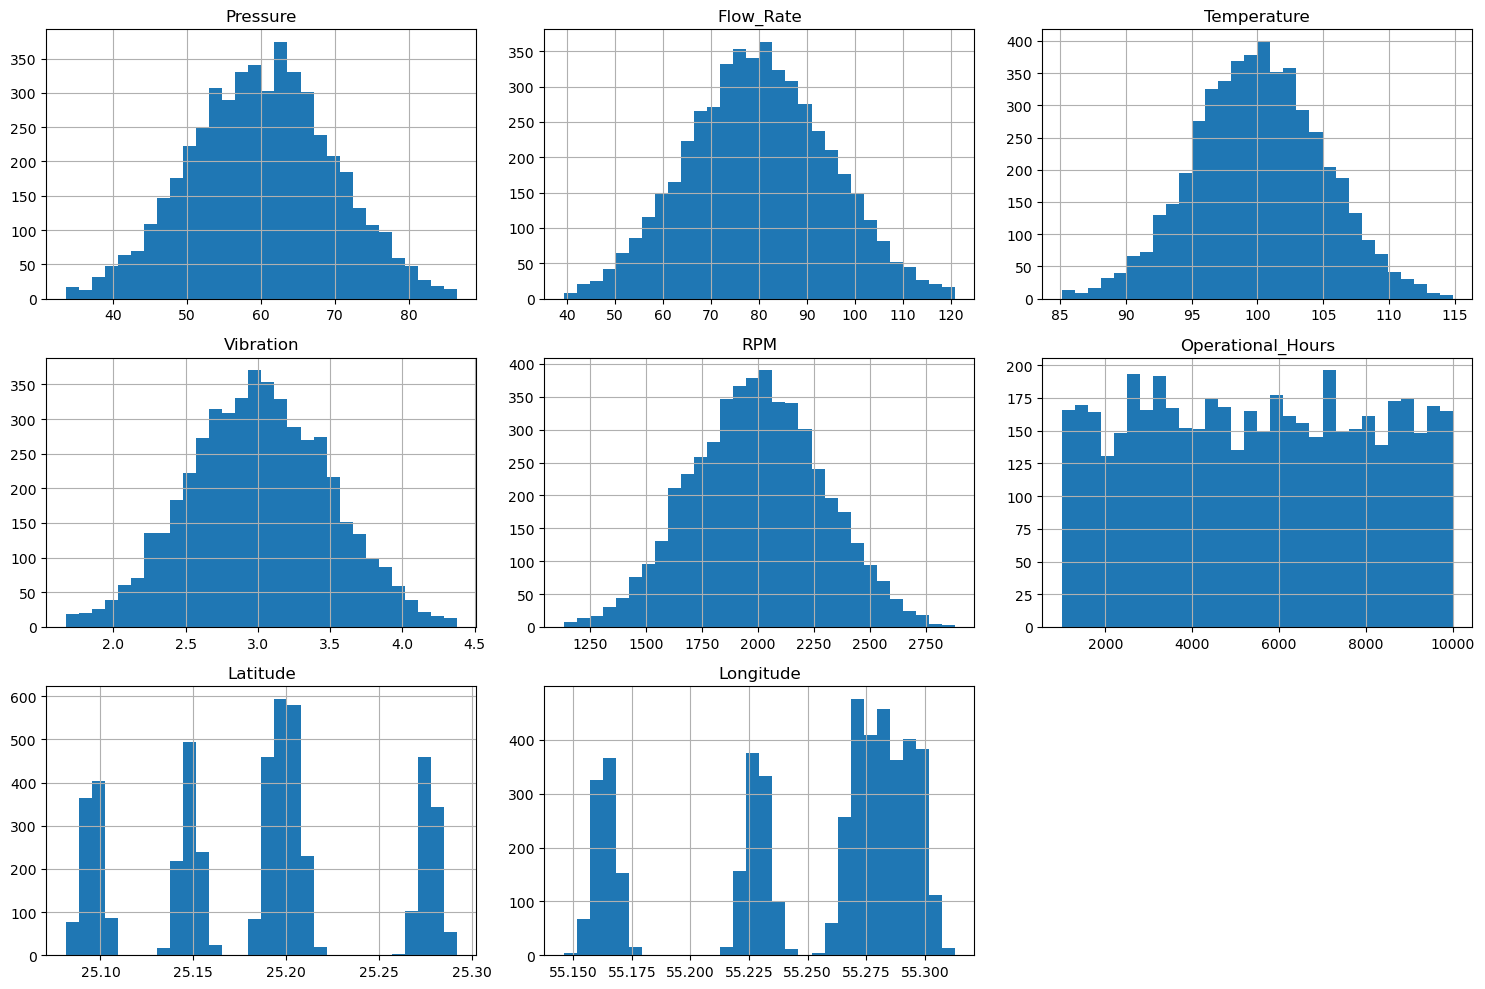

In [37]:
df[numeric_columns].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()



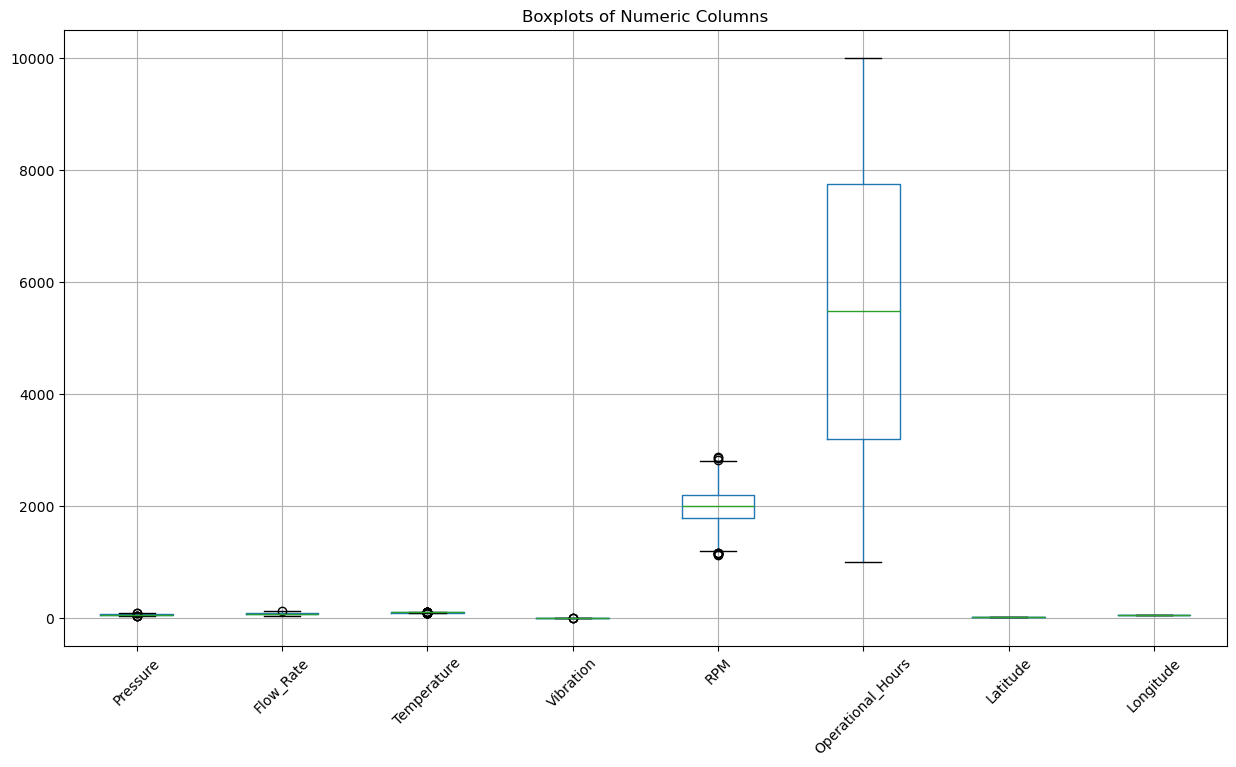

In [38]:
plt.figure(figsize=(15,8))
df[numeric_columns].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Columns")
plt.show()

In [39]:
categorical_columns = ['Zone','Block','Pipe','Location_Code','Leakage_Flag']

for col in categorical_columns:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())



Zone value counts:
Zone
Zone_5    995
Zone_4    992
Zone_1    974
Zone_2    964
Zone_3    932
Name: count, dtype: int64

Block value counts:
Block
Block_5    1009
Block_3     984
Block_2     976
Block_1     967
Block_4     921
Name: count, dtype: int64

Pipe value counts:
Pipe
Pipe_1    992
Pipe_5    990
Pipe_4    974
Pipe_3    968
Pipe_2    933
Name: count, dtype: int64

Location_Code value counts:
Location_Code
Zone_2_Block_5_Pipe_3    54
Zone_5_Block_1_Pipe_1    54
Zone_5_Block_3_Pipe_5    49
Zone_2_Block_2_Pipe_5    49
Zone_5_Block_2_Pipe_5    49
                         ..
Zone_3_Block_1_Pipe_2    27
Zone_5_Block_4_Pipe_5    26
Zone_5_Block_3_Pipe_3    26
Zone_3_Block_4_Pipe_3    25
Zone_2_Block_5_Pipe_4    25
Name: count, Length: 125, dtype: int64

Leakage_Flag value counts:
Leakage_Flag
0    4542
1     315
Name: count, dtype: int64


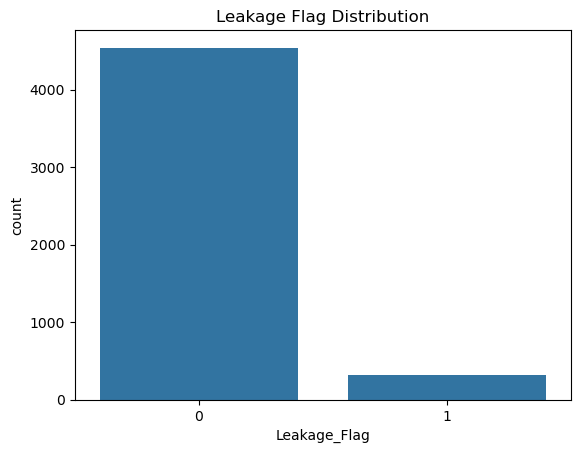

In [40]:
sns.countplot(x='Leakage_Flag', data=df)
plt.title("Leakage Flag Distribution")
plt.show()


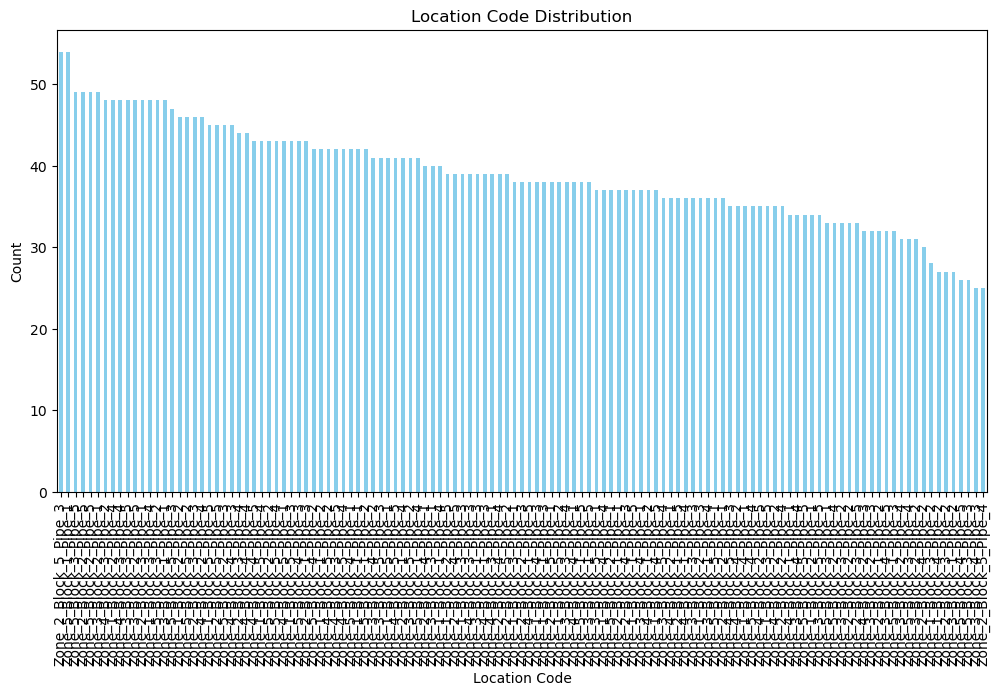

In [41]:
df["Location_Code"].value_counts().plot(
    kind="bar",
    figsize=(12,6),
    color="skyblue"
)
plt.title("Location Code Distribution")
plt.xlabel("Location Code")
plt.ylabel("Count")
plt.show()

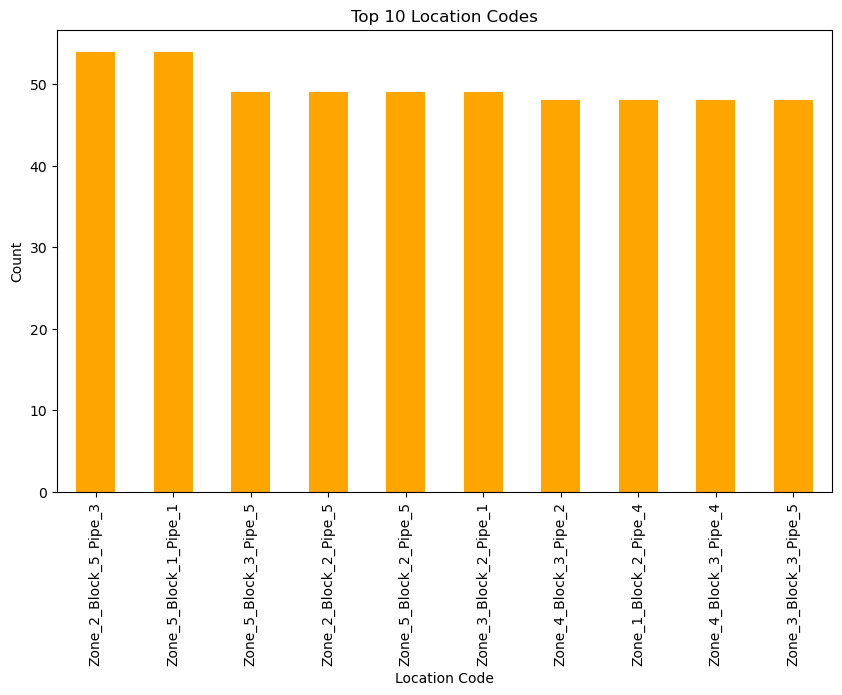

In [42]:
df["Location_Code"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,6),
    color="orange"
)
plt.title("Top 10 Location Codes")
plt.xlabel("Location Code")
plt.ylabel("Count")
plt.show()

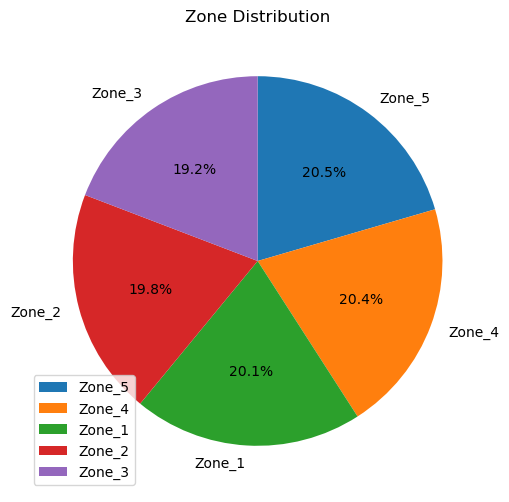

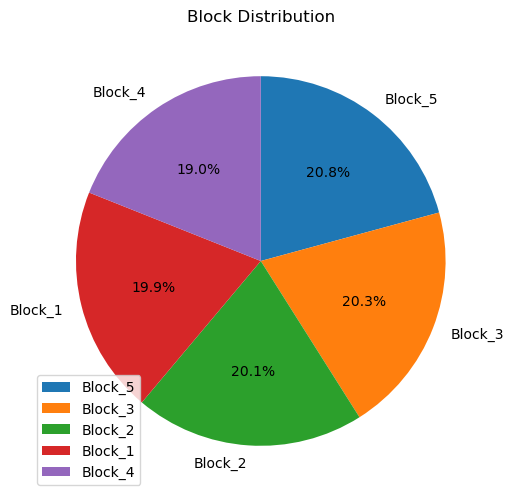

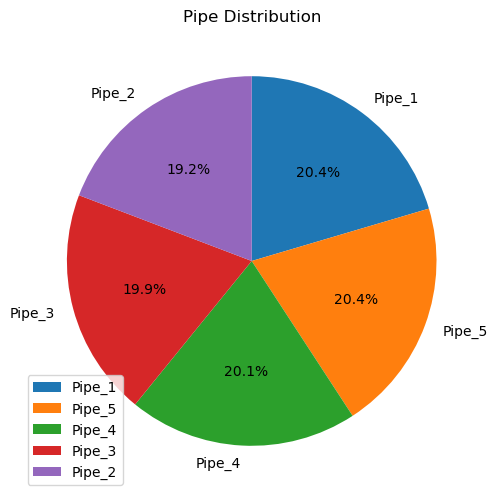

In [43]:
categorical_cols = ['Zone', 'Block', 'Pipe']

for col in categorical_cols:
    df[col].value_counts().plot(
        kind="pie",
        autopct='%1.1f%%',   
        startangle=90,      
        counterclock=False,  
        figsize=(6,6),
        legend=True
    )
    plt.ylabel('')
    plt.title(f'{col} Distribution')
    plt.show()

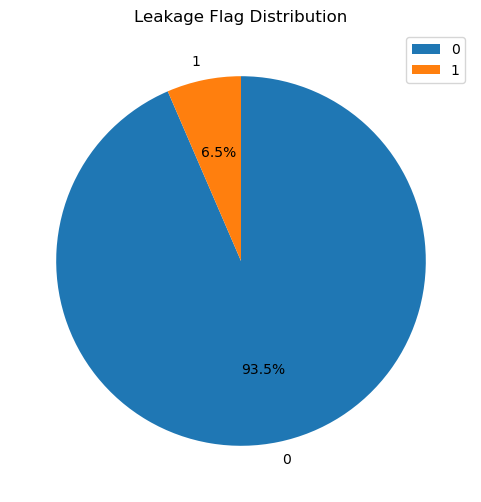

In [44]:
df["Leakage_Flag"].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    figsize=(6,6),
    legend=True
)

plt.ylabel('')
plt.title('Leakage Flag Distribution')
plt.show()

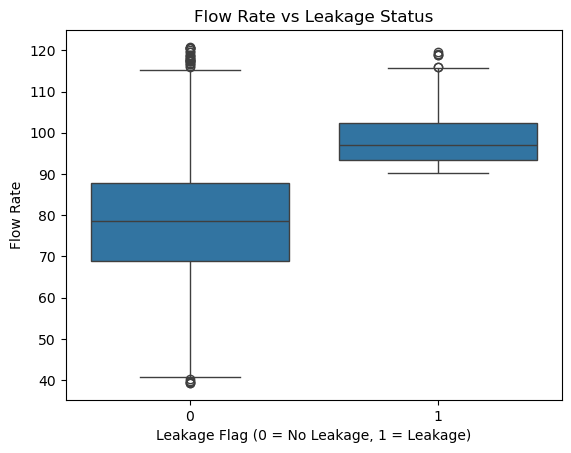

In [45]:
#BIVARIATE ANALYSIS
sns.boxplot(data=df, x='Leakage_Flag', y='Flow_Rate')

plt.title('Flow Rate vs Leakage Status')
plt.xlabel('Leakage Flag (0 = No Leakage, 1 = Leakage)')
plt.ylabel('Flow Rate')
plt.show()

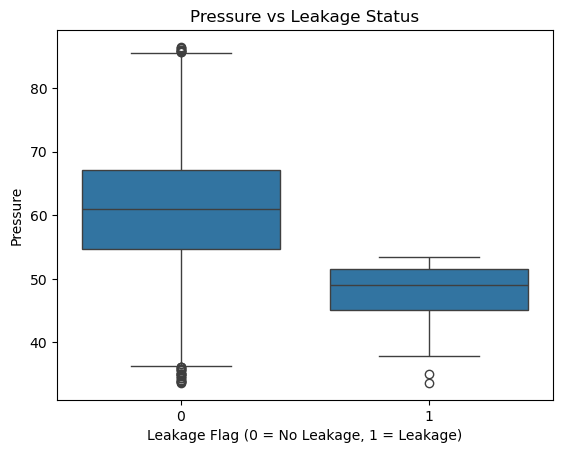

In [46]:
sns.boxplot(data=df, x='Leakage_Flag', y='Pressure')

plt.title('Pressure vs Leakage Status')
plt.xlabel('Leakage Flag (0 = No Leakage, 1 = Leakage)')
plt.ylabel('Pressure')
plt.show()


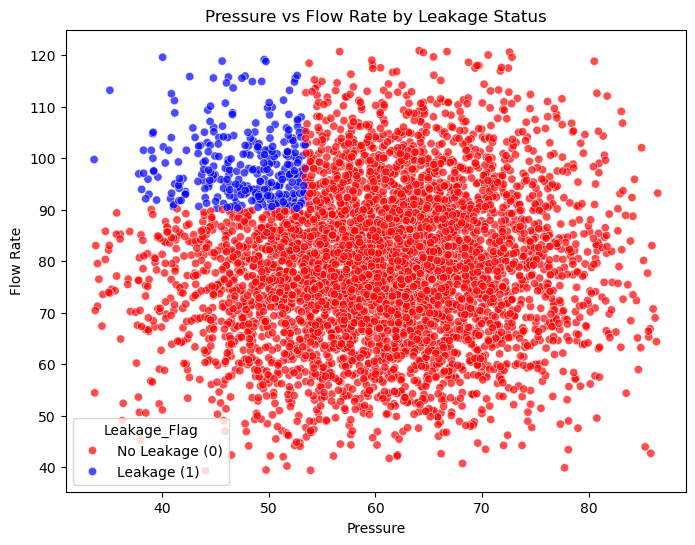

In [47]:
df['Leakage_Flag'] = df['Leakage_Flag'].astype('category')

plt.figure(figsize=(8,6))
scatter = sns.scatterplot(
    data=df,
    x='Pressure',
    y='Flow_Rate',
    hue='Leakage_Flag',
    palette={0:'red', 1:'blue'},  
    alpha=0.7
)

plt.title('Pressure vs Flow Rate by Leakage Status')
plt.xlabel('Pressure')
plt.ylabel('Flow Rate')


new_labels = ['No Leakage (0)', 'Leakage (1)']
for t, l in zip(scatter.legend_.texts, new_labels):
    t.set_text(l)

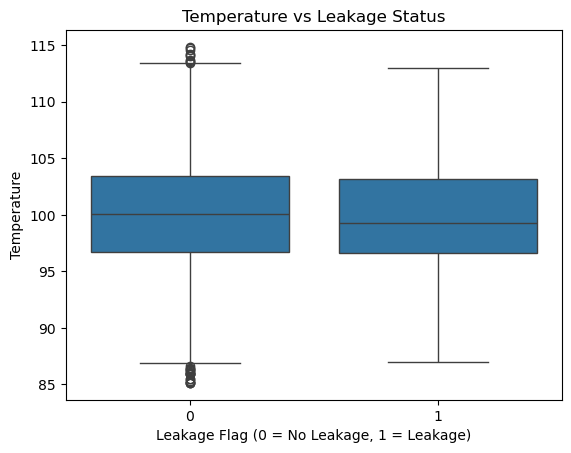

In [48]:
sns.boxplot(data=df, x='Leakage_Flag', y='Temperature')

plt.title('Temperature vs Leakage Status')
plt.xlabel('Leakage Flag (0 = No Leakage, 1 = Leakage)')
plt.ylabel('Temperature')
plt.show()

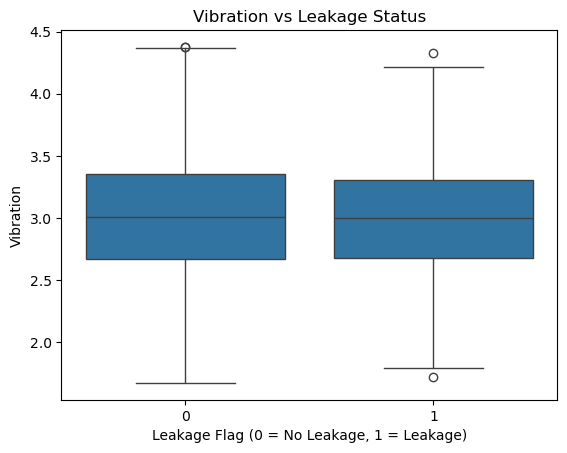

In [49]:
sns.boxplot(data=df, x='Leakage_Flag', y='Vibration')

plt.title('Vibration vs Leakage Status')
plt.xlabel('Leakage Flag (0 = No Leakage, 1 = Leakage)')
plt.ylabel('Vibration')
plt.show()

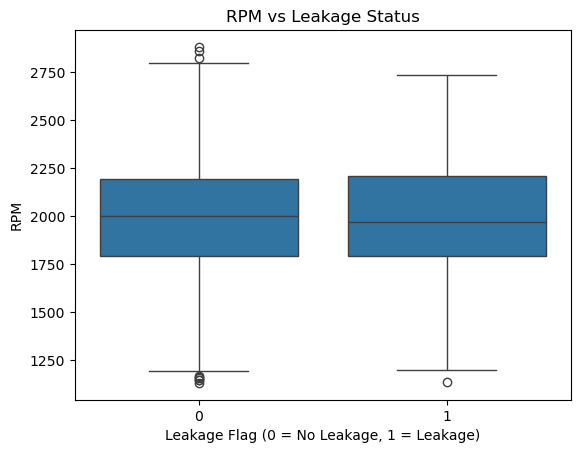

In [50]:
sns.boxplot(data=df, x='Leakage_Flag', y='RPM')

plt.title('RPM vs Leakage Status')
plt.xlabel('Leakage Flag (0 = No Leakage, 1 = Leakage)')
plt.ylabel('RPM')
plt.show()

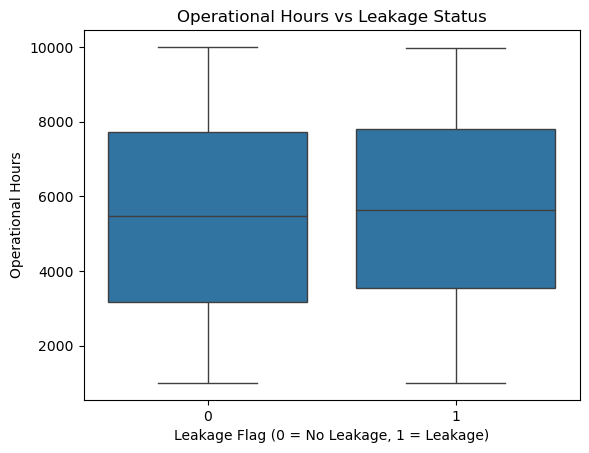

In [51]:
sns.boxplot(data=df, x='Leakage_Flag', y='Operational_Hours')

plt.title('Operational Hours vs Leakage Status')
plt.xlabel('Leakage Flag (0 = No Leakage, 1 = Leakage)')
plt.ylabel('Operational Hours')
plt.show()

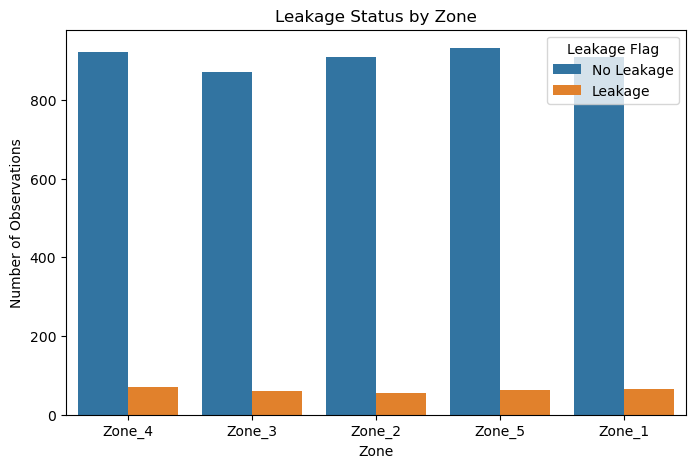

In [52]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Zone', hue='Leakage_Flag')
plt.title('Leakage Status by Zone')
plt.xlabel('Zone')
plt.ylabel('Number of Observations')
plt.legend(title='Leakage Flag', labels=['No Leakage', 'Leakage'])
plt.show()

In [53]:
zone_leakage = pd.crosstab(
    df['Zone'],
    df['Leakage_Flag'],
    normalize='index') * 100

zone_leakage

Leakage_Flag,0,1
Zone,,
Zone_1,93.326489,6.673511
Zone_2,94.294606,5.705394
Zone_3,93.454936,6.545064
Zone_4,92.842742,7.157258
Zone_5,93.668342,6.331658


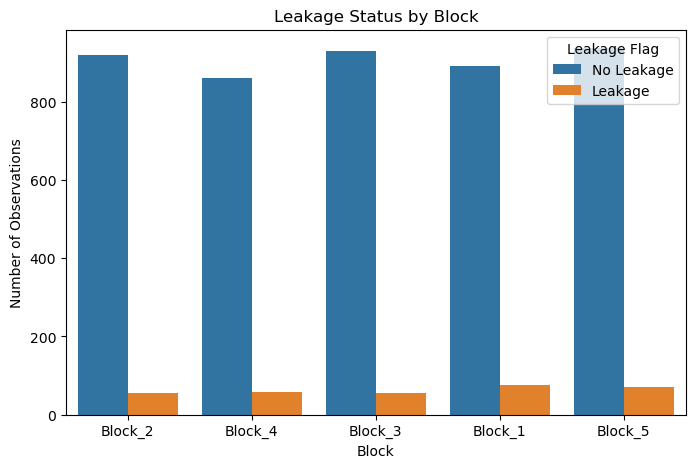

Leakage_Flag,0,1
Block,,
Block_1,92.140641,7.859359
Block_2,94.364754,5.635246
Block_3,94.512195,5.487805
Block_4,93.593920,6.406080
Block_5,92.963330,7.036670


In [54]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Block', hue='Leakage_Flag')

plt.title('Leakage Status by Block')
plt.xlabel('Block')
plt.ylabel('Number of Observations')
plt.legend(title='Leakage Flag', labels=['No Leakage', 'Leakage'])
plt.show()
block_leakage = pd.crosstab(
    df['Block'],
    df['Leakage_Flag'],
    normalize='index'
) * 100

block_leakage


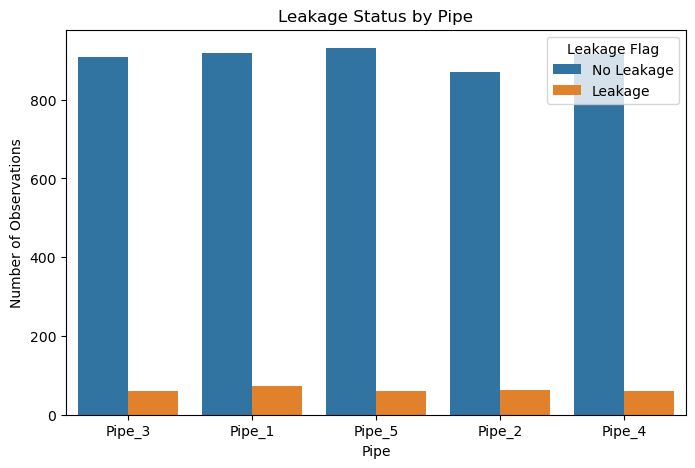

Leakage_Flag,0,1
Pipe,,
Pipe_1,92.641129,7.358871
Pipe_2,93.247588,6.752412
Pipe_3,93.698347,6.301653
Pipe_4,93.942505,6.057495
Pipe_5,94.040404,5.959596


In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Pipe', hue='Leakage_Flag')

plt.title('Leakage Status by Pipe')
plt.xlabel('Pipe')
plt.ylabel('Number of Observations')
plt.legend(title='Leakage Flag', labels=['No Leakage', 'Leakage'])
plt.show()
pipe_leakage = pd.crosstab(df['Pipe'], df['Leakage_Flag'], normalize='index') * 100

pipe_leakage

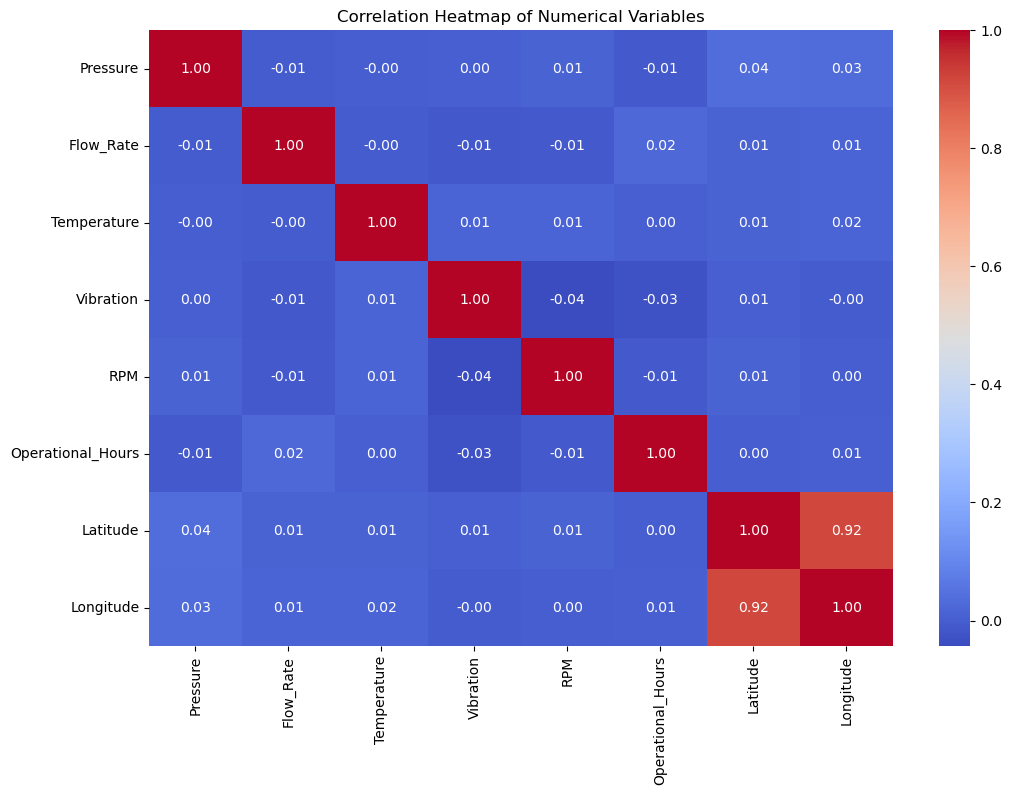

In [56]:
plt.figure(figsize=(12, 8))

correlation = df.select_dtypes(include='number').corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [57]:
#MULTIVARIATE ANALYSIS

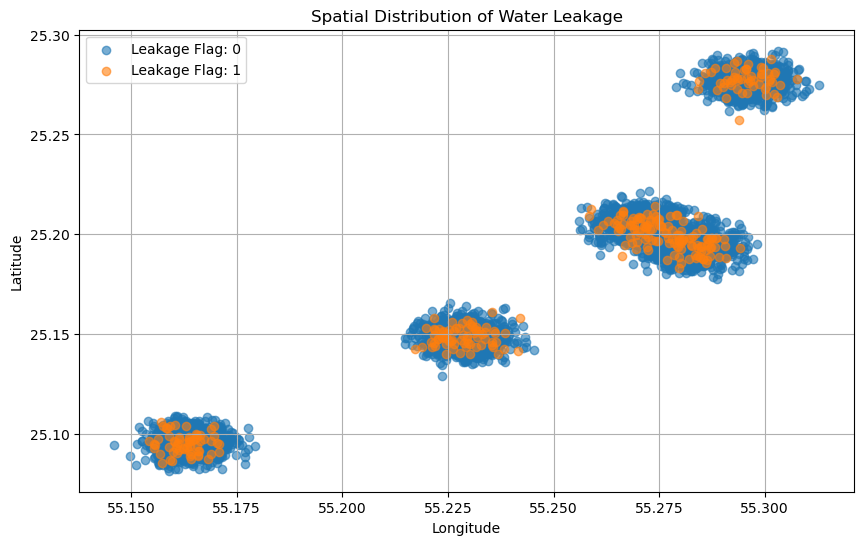

In [58]:
plt.figure(figsize=(10, 6))

for flag in clean_df['Leakage_Flag'].unique():
    subset = clean_df[clean_df['Leakage_Flag'] == flag]
    plt.scatter(
        subset['Longitude'],
        subset['Latitude'],
        label=f'Leakage Flag: {flag}',
        alpha=0.6
    )

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Distribution of Water Leakage')
plt.legend()
plt.grid(True)
plt.show()

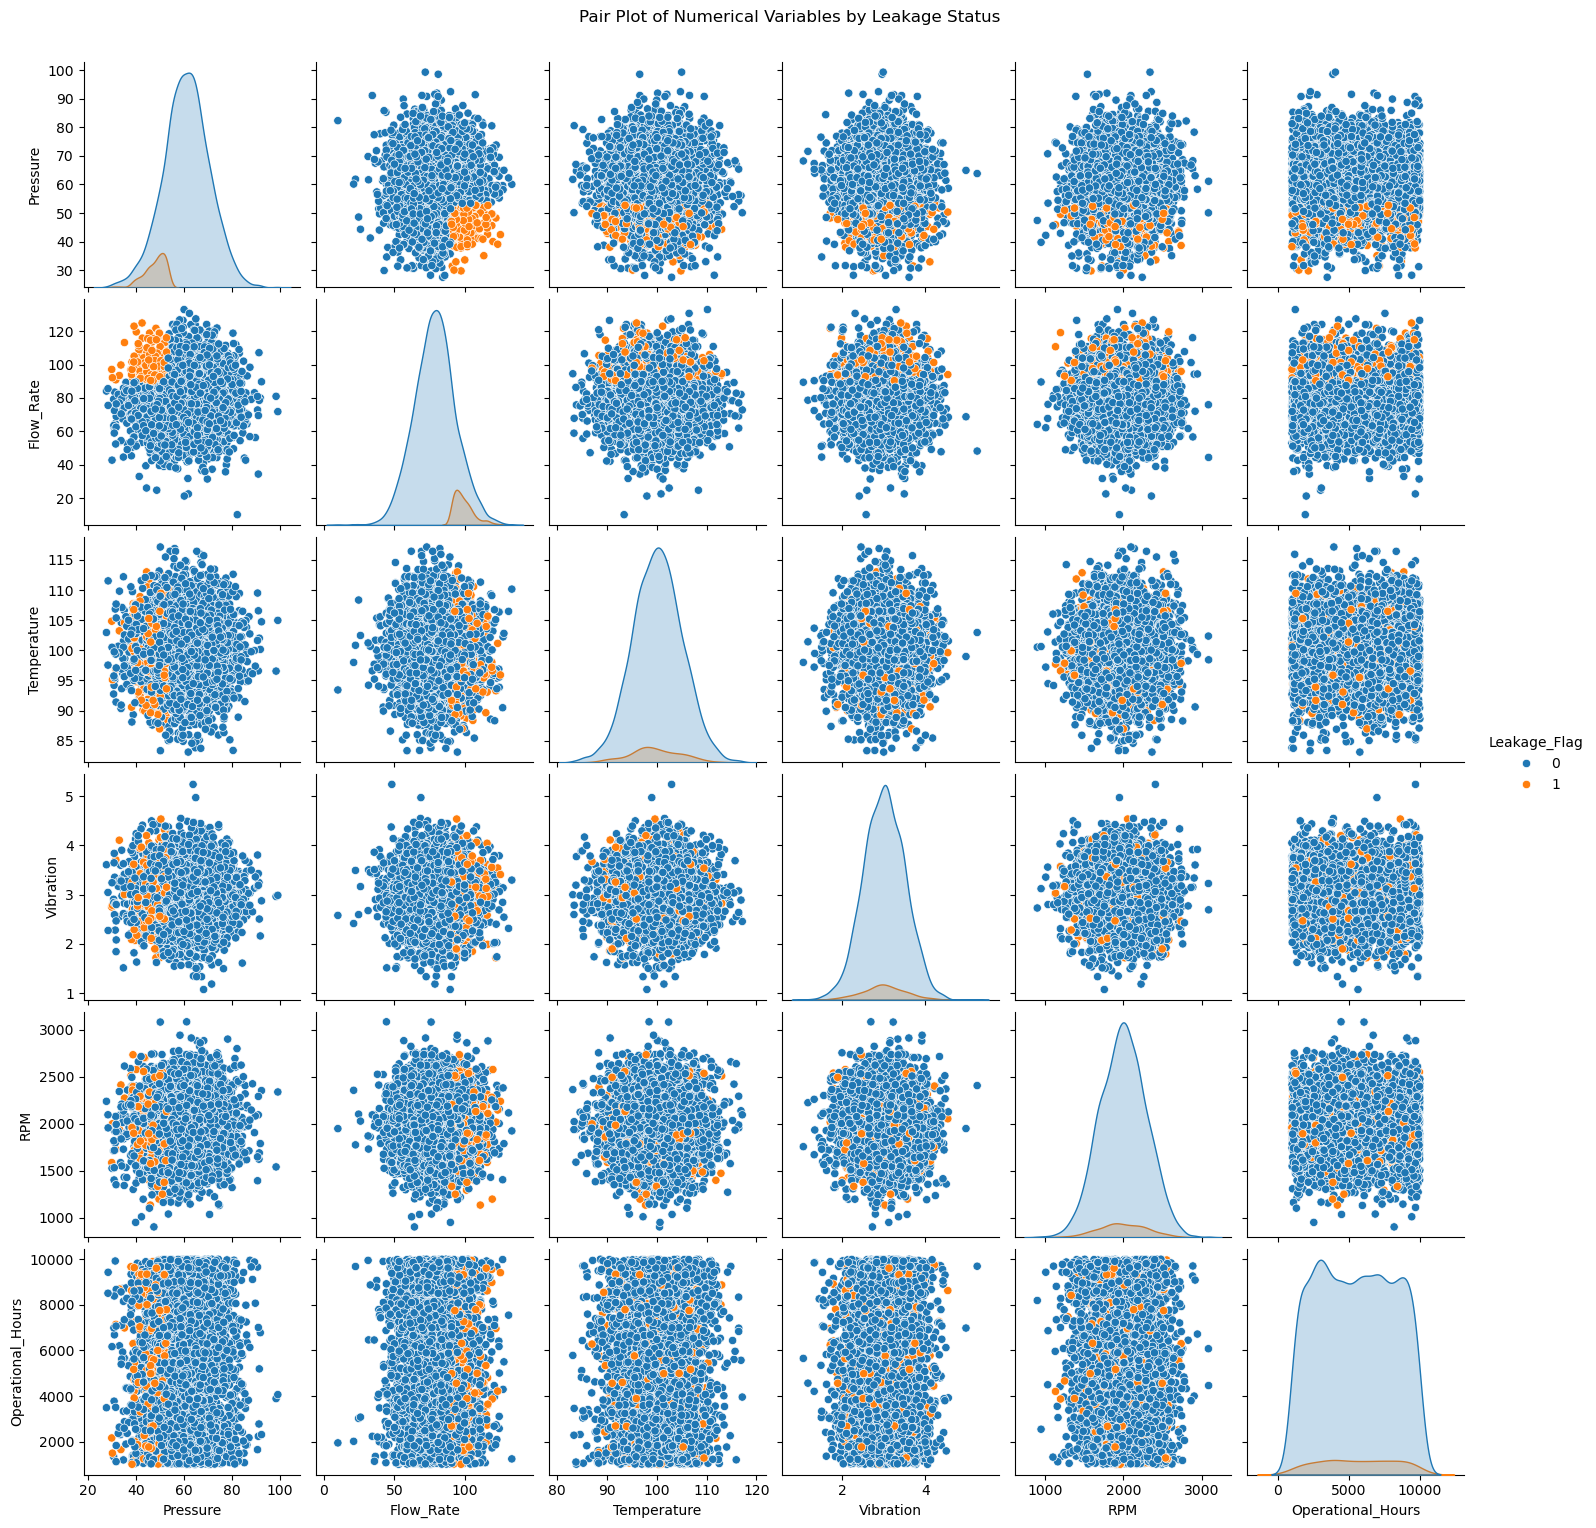

In [59]:
sns.pairplot(
    clean_df,
    vars=['Pressure', 'Flow_Rate', 'Temperature', 
          'Vibration', 'RPM', 'Operational_Hours'],
    hue='Leakage_Flag'
)

plt.suptitle('Pair Plot of Numerical Variables by Leakage Status', y=1.02)
plt.show()

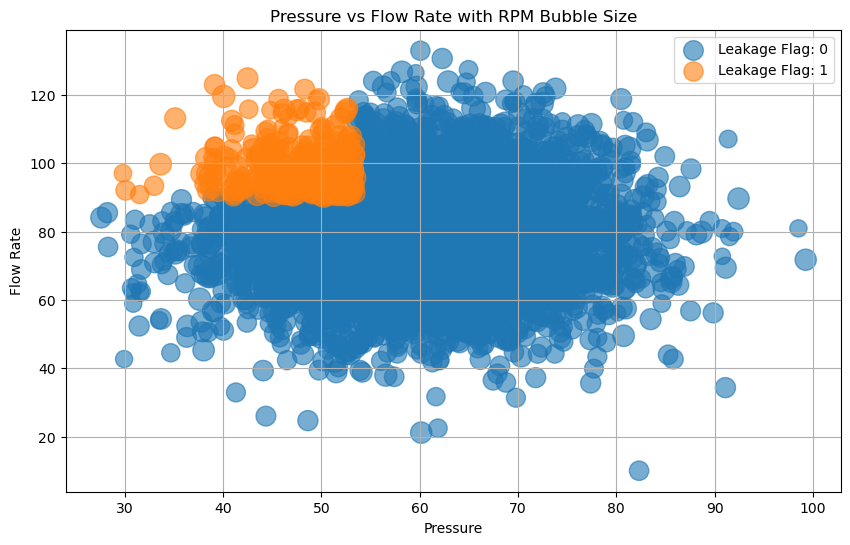

In [60]:
plt.figure(figsize=(10, 6))

for flag in clean_df['Leakage_Flag'].unique():
    subset = clean_df[clean_df['Leakage_Flag'] == flag]
    
    plt.scatter(
        subset['Pressure'],
        subset['Flow_Rate'],
        s=subset['RPM'] / 10,
        alpha=0.6,
        label=f'Leakage Flag: {flag}'
    )

plt.xlabel('Pressure')
plt.ylabel('Flow Rate')
plt.title('Pressure vs Flow Rate with RPM Bubble Size')
plt.legend()
plt.grid(True)
plt.show()


In [61]:
#FEATURE ENGINEERING

In [62]:
df['Pressure_Flow_Ratio'] = df['Pressure'] / df['Flow_Rate']

In [63]:
df[['Pressure', 'Flow_Rate', 'Pressure_Flow_Ratio']].head()

,Pressure,Flow_Rate,Pressure_Flow_Ratio
0,64.967142,73.643605,0.882183
1,58.617357,73.198788,0.800797
2,66.476885,53.065352,1.252736
3,75.230299,75.048647,1.002420
4,57.658466,90.992436,0.633662


In [64]:
df['Operational_Hours_Level'] = pd.cut(
    df['Operational_Hours'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

In [65]:
df[['Operational_Hours', 'Operational_Hours_Level']].head()

,Operational_Hours,Operational_Hours_Level
0,3380,Low
1,2235,Low
2,8762,High
3,8931,High
4,3403,Low


In [66]:
df['Vibration_Deviation'] = abs(df['Vibration'] - df['Vibration'].mean())

In [67]:
df[['Vibration', 'Vibration_Deviation']].head()

,Vibration,Vibration_Deviation
0,2.928288,0.081425
1,2.983672,0.026041
2,3.032147,0.022434
3,3.473431,0.463718
4,2.626391,0.383322


In [68]:
df = pd.get_dummies(df, columns=['Zone'], dtype=int)

In [69]:
df.head()

,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Block,Pipe,Location_Code,Latitude,Longitude,Leakage_Flag,Pressure_Flow_Ratio,Operational_Hours_Level,Vibration_Deviation,Zone_Zone_1,Zone_Zone_2,Zone_Zone_3,Zone_Zone_4,Zone_Zone_5
0,64.967142,73.643605,96.607526,2.928288,2104.485874,3380,Block_2,Pipe_3,Zone_4_Block_2_Pipe_3,25.162560,55.238018,0,0.882183,Low,0.081425,0,0,0,1,0
1,58.617357,73.198788,98.472503,2.983672,2084.997078,2235,Block_4,Pipe_1,Zone_3_Block_4_Pipe_1,25.090473,55.162476,0,0.800797,Low,0.026041,0,0,1,0,0
2,66.476885,53.065352,97.013095,3.032147,1719.044046,8762,Block_2,Pipe_5,Zone_2_Block_2_Pipe_5,25.279196,55.287601,0,1.252736,High,0.022434,0,1,0,0,0
3,75.230299,75.048647,100.552090,3.473431,2173.875267,8931,Block_3,Pipe_2,Zone_5_Block_3_Pipe_2,25.198326,55.269765,0,1.002420,High,0.463718,0,0,0,0,1
4,57.658466,90.992436,105.985893,2.626391,1552.975197,3403,Block_1,Pipe_1,Zone_3_Block_1_Pipe_1,25.099630,55.166098,0,0.633662,Low,0.383322,0,0,1,0,0


In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_to_scale = [
    'Pressure',
    'Flow_Rate',
    'Temperature',
    'Vibration',
    'RPM',
    'Operational_Hours',
    'Pressure_Flow_Ratio',
    'Vibration_Deviation'
]


In [71]:
df[features_to_scale].describe()

,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Pressure_Flow_Ratio,Vibration_Deviation
count,4.857000e+03,4.857000e+03,4.857000e+03,4.857000e+03,4.857000e+03,4.857000e+03,4.857000e+03,4.857000e+03
mean,-1.144007e-15,-1.462925e-16,-4.154707e-16,-6.656309e-16,5.997993e-17,-1.682364e-16,9.362721e-17,-1.404408e-16
std,1.000103e+00,1.000103e+00,1.000103e+00,1.000103e+00,1.000103e+00,1.000103e+00,1.000103e+00,1.000103e+00
min,-2.752584e+00,-2.756527e+00,-3.033805e+00,-2.753094e+00,-2.966080e+00,-1.721607e+00,-2.313365e+00,-1.353474e+00
25%,-6.866024e-01,-6.866151e-01,-6.810720e-01,-6.975115e-01,-7.035373e-01,-8.766861e-01,-7.051954e-01,-8.153719e-01
50%,5.298090e-03,-9.935993e-03,-1.631977e-03,-1.719630e-04,8.127183e-03,-1.438386e-03,-1.366685e-01,-1.779830e-01
75%,6.768965e-01,6.947945e-01,6.778423e-01,6.991051e-01,6.866235e-01,8.672833e-01,5.591680e-01,6.107317e-01
max,2.742674e+00,2.773193e+00,3.006312e+00,2.814132e+00,3.036876e+00,1.732550e+00,6.062791e+00,3.382576e+00


In [72]:
pd.set_option('display.float_format', '{:.4f}'.format)
df[features_to_scale].describe()

,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Pressure_Flow_Ratio,Vibration_Deviation
count,4857.0000,4857.0000,4857.0000,4857.0000,4857.0000,4857.0000,4857.0000,4857.0000
mean,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001
min,-2.7526,-2.7565,-3.0338,-2.7531,-2.9661,-1.7216,-2.3134,-1.3535
25%,-0.6866,-0.6866,-0.6811,-0.6975,-0.7035,-0.8767,-0.7052,-0.8154
50%,0.0053,-0.0099,-0.0016,-0.0002,0.0081,-0.0014,-0.1367,-0.1780
75%,0.6769,0.6948,0.6778,0.6991,0.6866,0.8673,0.5592,0.6107
max,2.7427,2.7732,3.0063,2.8141,3.0369,1.7326,6.0628,3.3826


In [73]:
correlation = df.select_dtypes(include='number').corrwith(
    df['Leakage_Flag'].astype(int)
).sort_values(ascending=False)

correlation


Flow_Rate              0.3347
Zone_Zone_4            0.0138
Operational_Hours      0.0127
Zone_Zone_1            0.0038
Vibration_Deviation    0.0015
Zone_Zone_3            0.0012
Zone_Zone_5           -0.0032
RPM                   -0.0051
Vibration             -0.0085
Longitude             -0.0112
Latitude              -0.0131
Zone_Zone_2           -0.0158
Temperature           -0.0188
Pressure              -0.3336
Pressure_Flow_Ratio   -0.3789
dtype: float64

In [74]:
selected_features = [
    'Pressure_Flow_Ratio',
    'Flow_Rate',
    'Pressure'
]

In [75]:
features = [
    'Pressure',
    'Flow_Rate',
    'Temperature',
    'Vibration',
    'RPM',
    'Operational_Hours',
    'Pressure_Flow_Ratio',
    'Vibration_Deviation',
    'Latitude',
    'Longitude'
]

X = df[features]
y = df['Leakage_Flag'].astype(int)

In [76]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

Pressure_Flow_Ratio   0.3811
Flow_Rate             0.3156
Pressure              0.2601
Vibration_Deviation   0.0071
Temperature           0.0070
Latitude              0.0068
Longitude             0.0062
RPM                   0.0055
Operational_Hours     0.0054
Vibration             0.0053
dtype: float64

In [77]:
#MACHINE LEARNING MODEL

In [78]:
X = df[['Pressure_Flow_Ratio', 'Flow_Rate', 'Pressure']]
y = df['Leakage_Flag'].astype(int)

In [79]:
X.head()

,Pressure_Flow_Ratio,Flow_Rate,Pressure
0,0.5045,-0.4276,0.5075
1,0.1034,-0.4578,-0.1533
2,2.3305,-1.8235,0.6647
3,1.0970,-0.3323,1.5757
4,-0.7202,0.7493,-0.2531


In [80]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Leakage_Flag, dtype: int64

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [82]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(3885, 3)
(972, 3)
(3885,)
(972,)


In [83]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()


In [84]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [85]:
y_pred = model.predict(X_test)

In [86]:
y_pred[:10]

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [87]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9526748971193416


In [88]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
[[894  10]
 [ 36  32]]
Accuracy: 0.9526748971193416
Precision: 0.7619047619047619
Recall: 0.47058823529411764
F1 Score: 0.5818181818181818


In [89]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9601029601029601
Testing Accuracy: 0.9526748971193416


In [90]:
print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of records: 4857
Number of columns: 20


In [91]:
print(df.shape)
print(df.columns.tolist())

(4857, 20)
['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours', 'Block', 'Pipe', 'Location_Code', 'Latitude', 'Longitude', 'Leakage_Flag', 'Pressure_Flow_Ratio', 'Operational_Hours_Level', 'Vibration_Deviation', 'Zone_Zone_1', 'Zone_Zone_2', 'Zone_Zone_3', 'Zone_Zone_4', 'Zone_Zone_5']


In [92]:
X = df.drop('Leakage_Flag', axis=1)
y = df['Leakage_Flag']

In [93]:
print(model.feature_names_in_)


['Pressure_Flow_Ratio' 'Flow_Rate' 'Pressure']


In [94]:
X = df[['Pressure_Flow_Ratio', 'Flow_Rate', 'Pressure']]
y = df['Leakage_Flag']

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.24,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

In [96]:
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))


Training: 3691
Validation: 583
Testing: 583


In [97]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross-validation scores: [0.95399188 0.96070461 0.95257453 0.95799458 0.95934959]
Average CV Score: 0.956923037430645


In [98]:
y_val_pred = model.predict(X_val)

In [99]:
from sklearn.metrics import accuracy_score
val_accuracy = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.9588336192109777


In [100]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression()

final_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [101]:
y_test_pred = final_model.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Final Testing Accuracy:", test_accuracy)

Final Testing Accuracy: 0.9554030874785592


In [103]:
y_test_probability = final_model.predict_proba(X_test)
print(y_test_probability[:10])

[[9.51703198e-01 4.82968023e-02]
 [9.99999761e-01 2.39218122e-07]
 [3.78497743e-01 6.21502257e-01]
 [9.99999479e-01 5.20664771e-07]
 [9.99987801e-01 1.21985432e-05]
 [9.98313873e-01 1.68612653e-03]
 [9.99959395e-01 4.06050625e-05]
 [9.08143842e-01 9.18561584e-02]
 [9.82628335e-01 1.73716652e-02]
 [9.91360102e-01 8.63989789e-03]]


In [104]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_test_pred)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
[[537  10]
 [ 16  20]]
Accuracy: 0.9554030874785592
Precision: 0.6666666666666666
Recall: 0.5555555555555556
F1 Score: 0.6060606060606061


In [105]:
print("Model:")
print(final_model)

print("\nModel type:")
print(type(final_model))

print("\nFeatures used:")
print(X_train.columns.tolist())

Model:
LogisticRegression()

Model type:
<class 'sklearn.linear_model._logistic.LogisticRegression'>

Features used:
['Pressure_Flow_Ratio', 'Flow_Rate', 'Pressure']


In [106]:
import joblib

joblib.dump(final_model, "final_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [117]:
print(X.head(10))

   Pressure_Flow_Ratio  Flow_Rate  Pressure
0               0.5045    -0.4276    0.5075
1               0.1034    -0.4578   -0.1533
2               2.3305    -1.8235    0.6647
3               1.0970    -0.3323    1.5757
4              -0.7202     0.7493   -0.2531
5               0.8238    -1.2930   -0.2531
6               0.0588     1.0705    1.6341
7              -0.0235     0.4999    0.7893
8               0.1078    -0.7435   -0.4980
9               0.2971    -0.1404    0.5552


In [115]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [116]:
import os
print([f for f in os.listdir() if f.endswith(".pkl")])

['final_model.pkl', 'scaler.pkl']


In [111]:
print(X.columns.tolist())

['Pressure_Flow_Ratio', 'Flow_Rate', 'Pressure']


In [4]:
import joblib

scaler = joblib.load("scaler.pkl")

print("Feature means:")
for feature, mean in zip(scaler.feature_names_in_, scaler.mean_):
    print(feature, "=", mean)

Feature means:
Pressure = 60.0905862182698
Flow_Rate = 79.9469046256286
Temperature = 100.05813419358459
Vibration = 3.009713010891649
RPM = 1995.6036117396243
Operational_Hours = 5484.746963145975
Pressure_Flow_Ratio = 0.7798155673325127
Vibration_Deviation = 0.3906944048490065
